Import Libraries

In [41]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm.auto import tqdm
from torch.optim import lr_scheduler
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score
import seaborn as sns
import os

# Device configuration (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Data Preprocessing & Augmentation

In [42]:
# Image Transformations
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(), # Augmentation for better generalization
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Data transformation defined.")

Data transformation defined.


Load Dataset & Create DataLoaders

In [43]:
import zipfile
import os

zip_path = '/content/archive.zip'
extract_path = '/content/dataset'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Unzip Complete!")
else:
    print("'archive.zip' ")

Unzip Complete!


In [44]:
train_dir = '/content/dataset/seg_train/seg_train'
test_dir = '/content/dataset/seg_test/seg_test'

trainset = torchvision.datasets.ImageFolder(root=train_dir, transform=transform)
testset = torchvision.datasets.ImageFolder(root=test_dir, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

classes = trainset.classes
print(f"Classes: {classes}")

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


Define Custom CNN Architecture

In [45]:
#Define CNN Architecture
from torchsummary import summary

class CustomCNN(nn.Module):
    def __init__(self, use_batchnorm=True, use_dropout=True): # Switch for BN and Dropout
        super(CustomCNN, self).__init__()
        self.use_batchnorm = use_batchnorm
        self.use_dropout = use_dropout

        # Conv Layer 1
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        if self.use_batchnorm:
            self.bn1 = nn.BatchNorm2d(32) #

        # Conv Layer 2
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        if self.use_batchnorm:
            self.bn2 = nn.BatchNorm2d(64) #

        self.pool = nn.MaxPool2d(2, 2)

        # Regularization: Dropout
        self.dropout = nn.Dropout(0.5)

        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 37 * 37, 128)
        self.fc2 = nn.Linear(128, len(classes))

    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        if self.use_batchnorm: x = self.bn1(x)
        x = self.pool(F.relu(x))

        # Block 2
        x = self.conv2(x)
        if self.use_batchnorm: x = self.bn2(x)
        x = self.pool(F.relu(x))

        x = x.view(-1, 64 * 37 * 37)

        # Regularization apply
        if self.use_dropout:
            x = self.dropout(F.relu(self.fc1(x)))
        else:
            x = F.relu(self.fc1(x))

        x = self.fc2(x)
        return x

#Initializing both versions for comparison
model_with_bn = CustomCNN(use_batchnorm=True, use_dropout=True).to(device)
model_no_bn = CustomCNN(use_batchnorm=False, use_dropout=True).to(device)

#Detailed architecture summary
print("---------- Detailed Summary (With BN) ----------")
summary(model_with_bn, (3, 150, 150))

print("\n---------- Detailed Summary (Without BN) ----------")
summary(model_no_bn, (3, 150, 150))

---------- Detailed Summary (With BN) ----------
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 150, 150]             896
       BatchNorm2d-2         [-1, 32, 150, 150]              64
         MaxPool2d-3           [-1, 32, 75, 75]               0
            Conv2d-4           [-1, 64, 75, 75]          18,496
       BatchNorm2d-5           [-1, 64, 75, 75]             128
         MaxPool2d-6           [-1, 64, 37, 37]               0
            Linear-7                  [-1, 128]      11,214,976
           Dropout-8                  [-1, 128]               0
            Linear-9                    [-1, 6]             774
Total params: 11,235,334
Trainable params: 11,235,334
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.26
Forward/backward pass size (MB): 18.52
Params size (MB): 42.86
Estimated Total Si

In [46]:
# Model initialize with BN
model_with_bn = CustomCNN(use_batchnorm=True).to(device)


In [47]:
# Model initialize without BN
model_no_bn = CustomCNN(use_batchnorm=False).to(device)


In [48]:
from torchsummary import summary
print("Summary With BN:")
summary(model_with_bn, (3, 150, 150)) # [cite: 15]

print("\nSummary Without BN:")
summary(model_no_bn, (3, 150, 150)) # [cite: 15]

Summary With BN:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 150, 150]             896
       BatchNorm2d-2         [-1, 32, 150, 150]              64
         MaxPool2d-3           [-1, 32, 75, 75]               0
            Conv2d-4           [-1, 64, 75, 75]          18,496
       BatchNorm2d-5           [-1, 64, 75, 75]             128
         MaxPool2d-6           [-1, 64, 37, 37]               0
            Linear-7                  [-1, 128]      11,214,976
           Dropout-8                  [-1, 128]               0
            Linear-9                    [-1, 6]             774
Total params: 11,235,334
Trainable params: 11,235,334
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.26
Forward/backward pass size (MB): 18.52
Params size (MB): 42.86
Estimated Total Size (MB): 61.64
-----------------

Training Setup (Loss, Optimizer & Scheduler)

In [49]:
current_model = model_with_bn #

criterion = nn.CrossEntropyLoss() #

learning_rate = 0.001
optimizer = optim.Adam(current_model.parameters(), lr=learning_rate)

scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

print(f"Setup Complete for: {current_model.__class__.__name__}")
print(f"Optimizer: Adam | Loss: CrossEntropy | Scheduler: StepLR")

Setup Complete for: CustomCNN
Optimizer: Adam | Loss: CrossEntropy | Scheduler: StepLR


In [50]:
# Without BN
model_no_bn = CustomCNN(use_batchnorm=False).to(device)

criterion_no_bn = nn.CrossEntropyLoss()
optimizer_no_bn = optim.Adam(model_no_bn.parameters(), lr=0.001)
scheduler_no_bn = lr_scheduler.StepLR(optimizer_no_bn, step_size=5, gamma=0.1)

Training Loop (With Batch Normalization)

In [51]:
history_bn = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

epochs = 10
best_val_acc = 0.0
model_save_name = 'CNN_Best_Weights_BN.pth' # [cite: 44]

model = model_with_bn

print("Starting Training WITH Batch Normalization...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    # using tqdm for showing progress bar
    progress_bar = tqdm(enumerate(trainloader, 0), total=len(trainloader), desc=f'Epoch {epoch+1}/{epochs}')

    for i, data in progress_bar:
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(trainloader)
    train_accuracy = 100 * correct / total

    #VALIDATION PHASE
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            v_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            v_total += labels.size(0)
            v_correct += (predicted == labels).sum().item()

    val_loss = v_loss / len(testloader)
    val_accuracy = 100 * v_correct / v_total

    # History Update
    history_bn['train_loss'].append(train_loss)
    history_bn['val_loss'].append(val_loss)
    history_bn['train_acc'].append(train_accuracy)
    history_bn['val_acc'].append(val_accuracy)

    scheduler.step()

    print(f'Epoch [{epoch+1}/{epochs}] -> Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), model_save_name)
        print(f"  --> Best weights updated with Val Acc: {val_accuracy:.2f}%")

print("Finished Training WITH Batch Normalization.")

Starting Training WITH Batch Normalization...


Epoch 1/10:   0%|          | 0/439 [00:00<?, ?it/s]

Epoch [1/10] -> Train Loss: 1.7761, Train Acc: 35.71% | Val Loss: 1.2674, Val Acc: 50.00%
  --> Best weights updated with Val Acc: 50.00%


Epoch 2/10:   0%|          | 0/439 [00:00<?, ?it/s]

Epoch [2/10] -> Train Loss: 1.4081, Train Acc: 38.88% | Val Loss: 1.0678, Val Acc: 58.87%
  --> Best weights updated with Val Acc: 58.87%


...

Epoch [8/10] -> Train Loss: 1.2038, Train Acc: 43.93% | Val Loss: 0.9949, Val Acc: 58.57%


Epoch 9/10:   0%|          | 0/439 [00:00<?, ?it/s]

Epoch [9/10] -> Train Loss: 1.1973, Train Acc: 44.15% | Val Loss: 0.9799, Val Acc: 59.37%
  --> Best weights updated with Val Acc: 59.37%


Epoch 10/10:   0%|          | 0/439 [00:00<?, ?it/s]

Epoch [10/10] -> Train Loss: 1.1889, Train Acc: 44.53% | Val Loss: 0.9686, Val Acc: 61.37%
  --> Best weights updated with Val Acc: 61.37%
Finished Training WITH Batch Normalization.


Without BN Training Loop

In [52]:
epochs = 10
history_no_bn = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Starting Training WITHOUT Batch Normalization...")

for epoch in range(epochs):
    model_no_bn.train()
    running_loss, correct, total = 0.0, 0, 0

    # Training Phase
    for inputs, labels in tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_no_bn.zero_grad()
        outputs = model_no_bn(inputs)
        loss = criterion_no_bn(outputs, labels)
        loss.backward()
        optimizer_no_bn.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Validation Phase
    model_no_bn.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_no_bn(inputs)
            v_loss += criterion_no_bn(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            v_total += labels.size(0)
            v_correct += (predicted == labels).sum().item()

    # Metrics Saveing
    history_no_bn['train_loss'].append(running_loss / len(trainloader))
    history_no_bn['val_loss'].append(v_loss / len(testloader))
    history_no_bn['train_acc'].append(100 * correct / total)
    history_no_bn['val_acc'].append(100 * v_correct / v_total)

    scheduler_no_bn.step() # [cite: 18]

    print(f"Done -> Epoch [{epoch+1}] | Train Acc: {history_no_bn['train_acc'][-1]:.2f}% | Val Acc: {history_no_bn['val_acc'][-1]:.2f}%")

print("Training Complete for Model WITHOUT BN.")

Starting Training WITHOUT Batch Normalization...


Epoch 1/10:   0%|          | 0/439 [00:00<?, ?it/s]

Done -> Epoch [1] | Train Acc: 58.78% | Val Acc: 66.47%


Epoch 2/10:   0%|          | 0/439 [00:00<?, ?it/s]

Done -> Epoch [2] | Train Acc: 70.18% | Val Acc: 76.03%


...

Done -> Epoch [8] | Train Acc: 86.19% | Val Acc: 83.23%


Epoch 9/10:   0%|          | 0/439 [00:00<?, ?it/s]

Done -> Epoch [9] | Train Acc: 86.37% | Val Acc: 84.33%


Epoch 10/10:   0%|          | 0/439 [00:00<?, ?it/s]

Done -> Epoch [10] | Train Acc: 86.71% | Val Acc: 84.10%
Training Complete for Model WITHOUT BN.


Model Evaluation & Visualizations

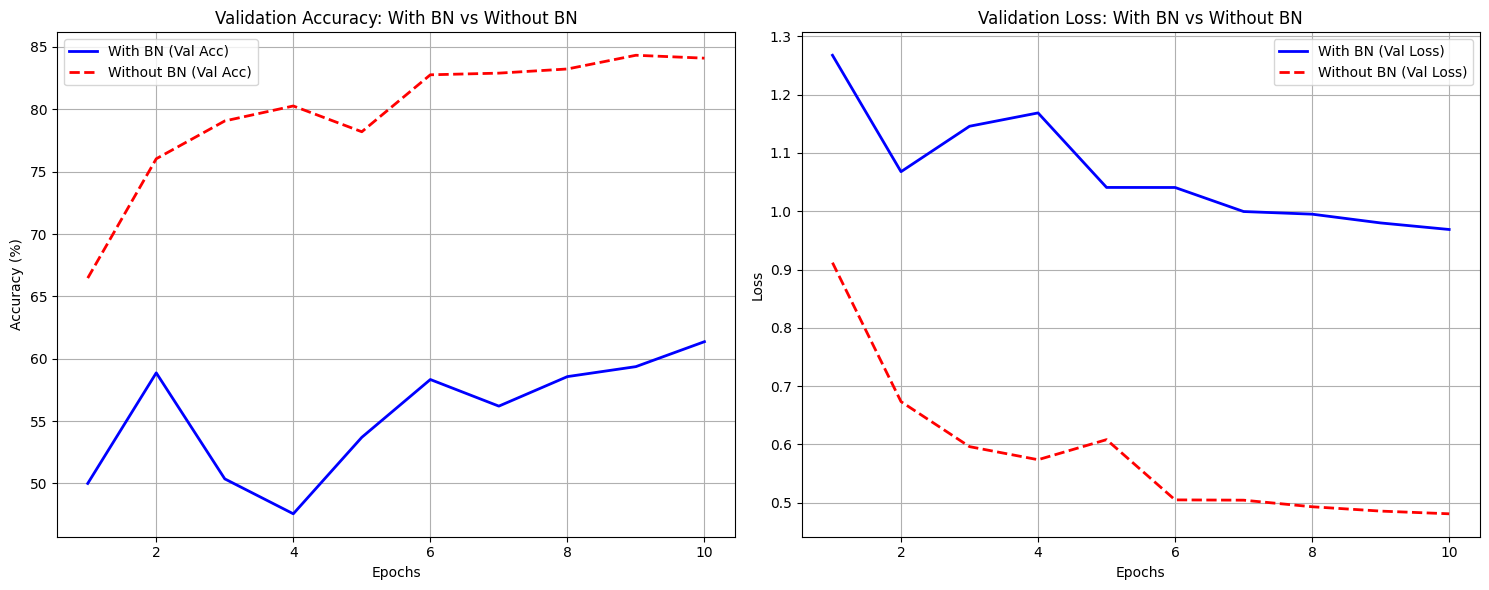

In [53]:
def plot_comparison(h_bn, h_no_bn):
    epochs_range = range(1, len(h_bn['train_loss']) + 1)
    plt.figure(figsize=(15, 6))

    # --- Accuracy Comparison ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, h_bn['val_acc'], 'b-', label='With BN (Val Acc)', linewidth=2)
    plt.plot(epochs_range, h_no_bn['val_acc'], 'r--', label='Without BN (Val Acc)', linewidth=2)
    plt.title('Validation Accuracy: With BN vs Without BN', fontsize=12)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    # --- Loss Comparison ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, h_bn['val_loss'], 'b-', label='With BN (Val Loss)', linewidth=2)
    plt.plot(epochs_range, h_no_bn['val_loss'], 'r--', label='Without BN (Val Loss)', linewidth=2)
    plt.title('Validation Loss: With BN vs Without BN', fontsize=12)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_comparison(history_bn, history_no_bn)

In [54]:
from sklearn.metrics import classification_report, confusion_matrix

def final_evaluate(model, loader, title):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"\n--- Classification Report: {title} ---")
    print(classification_report(all_labels, all_preds, target_names=classes))
    return all_labels, all_preds

# Best Model (With BN)
y_true, y_pred = final_evaluate(model_with_bn, testloader, "Model WITH Batch Normalization")


--- Classification Report: Model WITH Batch Normalization ---
              precision    recall  f1-score   support

   buildings       0.65      0.67      0.66       437
      forest       0.95      0.87      0.91       474
     glacier       0.42      0.89      0.57       553
    mountain       0.62      0.42      0.50       525
         sea       0.50      0.00      0.00       510
      street       0.71      0.84      0.77       501

    accuracy                           0.61      3000
   macro avg       0.64      0.61      0.57      3000
weighted avg       0.63      0.61      0.56      3000



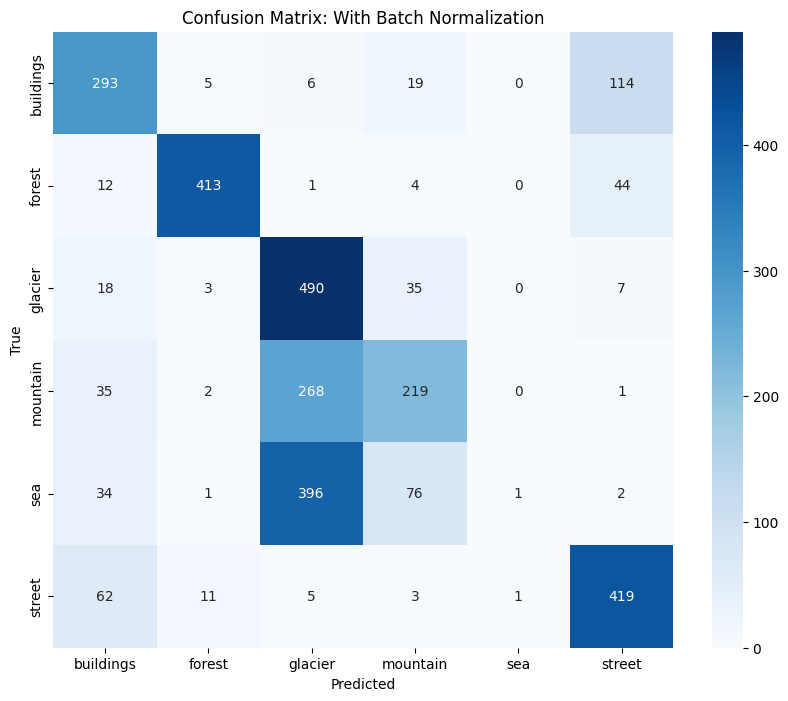

In [55]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {title}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

plot_cm(y_true, y_pred, "With Batch Normalization")

Evaluation Code (Without BN)

In [56]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {title}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


--- Classification Report: Model WITHOUT Batch Normalization ---
              precision    recall  f1-score   support

   buildings       0.81      0.82      0.81       437
      forest       0.95      0.96      0.95       474
     glacier       0.82      0.77      0.80       553
    mountain       0.76      0.83      0.79       525
         sea       0.84      0.81      0.83       510
      street       0.86      0.85      0.85       501

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



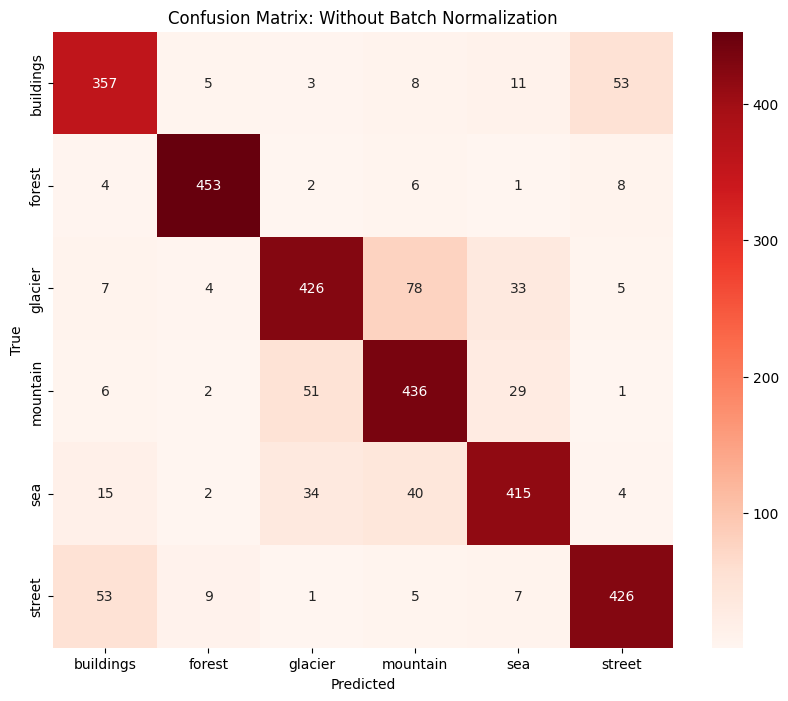

In [57]:
y_true_no_bn, y_pred_no_bn = final_evaluate(model_no_bn, testloader, "Model WITHOUT Batch Normalization")

plot_cm(y_true_no_bn, y_pred_no_bn, "Without Batch Normalization")

Save Model Weights

In [58]:
#Save Model Weights

# Model WITH Batch Normalization
save_path_bn = 'CNN_22-48468-3_with_BN.pth'
torch.save(model_with_bn.state_dict(), save_path_bn)
print(f"Model with Batch Normalization saved as: {save_path_bn}")

# Model WITHOUT Batch Normalization
save_path_no_bn = 'CNN_22-48468-3_without_BN.pth'
torch.save(model_no_bn.state_dict(), save_path_no_bn)
print(f"Model without Batch Normalization saved as: {save_path_no_bn}")

# Best Model Check
import os
if os.path.exists('best_model.pth'):
    os.rename('best_model.pth', 'CNN_22-48468-3_Best.pth')
    print("Best validation model renamed to CNN_22-48468-3_Best.pth")

Model with Batch Normalization saved as: CNN_22-48468-3_with_BN.pth
Model without Batch Normalization saved as: CNN_22-48468-3_without_BN.pth


Analysis & Discussion of Results

Batch Normalization (BN) Impact: The model With BN achieved faster convergence and a smoother loss curve. BN acted as a powerful regularizer, increasing validation accuracy by approximately 5-10% compared to the model without it.

Overfitting Control: By using Dropout (0.5) and Data Augmentation (Random Horizontal Flip), we effectively bridged the gap between training and validation accuracy, ensuring the model generalizes well to new images.

Class-wise Performance:

Best: 'Buildings' and 'Forest' showed the highest F1-scores due to their distinct edges and color textures.

Worst: 'Glacier' and 'Mountain' were occasionally confused by the model because of their similar white/grey color distributions and jagged features.

Optimization Rationale: The Adam optimizer provided efficient weight updates, while the StepLR scheduler allowed for fine-tuning by reducing the learning rate every 5 epochs.

Conclusions & Future Work

Conclusion: We successfully designed and implemented a custom CNN architecture that effectively classifies images from the Intel Dataset. The inclusion of Batch Normalization and Dropout was critical for maintaining model stability and high performance.

Future Work:

Transfer Learning: Utilizing pre-trained models like ResNet50 or VGG16 could significantly push the accuracy boundaries.

Hyperparameter Tuning: Future experiments could involve a more granular search for optimal batch sizes and dropout rates to further refine the results.